# Health-Personalized Food Recommender System
**Dataset:** Food.com — `RAW_recipes.csv` + `interactions_train/test/validation.csv`

| Section | Work Package |
|---------|-------------|
| 1. Setup & Load | — |
| 2. Data Scraping | WP: Data Scraping |
| 3. Data Cleaning | WP: Data Quality |
| 4. Data Annotation | WP: Data Annotation |
| 5. Vector Embeddings | WP: Vector Embeddings |
| 6. Recommender System | WP: Recommender System |
| 7. Evaluation (Precision@k / Recall@k — 2 methods) | WP: Performance Evaluation |
| 8. Hyperparameter Tuning | WP: Hyperparameter Tuning |
| 9. Experiment Logging | WP: Experiments Logging |
| 10. Perturbation Analysis | WP: Perturbation Analysis |
| 11. Frontend | WP: Frontend Application |
| 12. Summary | — |


---
## 1. Setup & Load


In [1]:
import sys
!{sys.executable} -m pip install -q pandas numpy scikit-learn matplotlib \
    scikit-surprise optuna wandb requests
print('Done')


Done


In [2]:
import warnings; warnings.filterwarnings('ignore')
import os, ast, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import requests

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#F8F7F4',
    'axes.grid':True,'grid.color':'#E0DED8',
    'axes.spines.top':False,'axes.spines.right':False,
})
C_AFTER='#0F6E56'; C_BEFORE='#A32D2D'; C_FLAG='#BA7517'; C_PURPLE='#534AB7'

os.makedirs('data',exist_ok=True)
os.makedirs('plots',exist_ok=True)
os.makedirs('models',exist_ok=True)
np.random.seed(42); random.seed(42)

def validate(condition, label, expected, actual):
    status = '✅ PASS' if condition else '❌ FAIL'
    print(f'{status}  {label}  |  expected: {expected}  |  actual: {actual}')
    if not condition:
        raise AssertionError(f'Validation failed: {label}')

print('Setup complete')


Setup complete


In [3]:
# ── Load recipes ──────────────────────────────────────────────────────────────
df_recipes_raw = pd.read_csv('data/RAW_recipes.csv')

NUTRITION_COLS = ['calories','total_fat_g','sugar_g','sodium_mg',
                   'protein_g','sat_fat_g','carbs_g']

def parse_nutrition(s):
    try:
        v = ast.literal_eval(str(s))
        return v if len(v)==7 else [np.nan]*7
    except: return [np.nan]*7

nutr = pd.DataFrame(
    df_recipes_raw['nutrition'].apply(parse_nutrition).tolist(),
    columns=NUTRITION_COLS)
df_recipes_raw = pd.concat(
    [df_recipes_raw.drop(columns=['nutrition']), nutr], axis=1)
df_recipes_raw['tags_list'] = df_recipes_raw['tags'].apply(
    lambda s: ast.literal_eval(str(s)) if pd.notna(s) else [])
for col in NUTRITION_COLS + ['minutes']:
    df_recipes_raw[col] = pd.to_numeric(df_recipes_raw[col], errors='coerce')

print(f'Recipes: {len(df_recipes_raw):,}')
print(df_recipes_raw[['name'] + NUTRITION_COLS].head(3).to_string(index=False))


Recipes: 231,637
                                      name  calories  total_fat_g  sugar_g  sodium_mg  protein_g  sat_fat_g  carbs_g
arriba   baked winter squash mexican style      51.5          0.0     13.0        0.0        2.0        0.0      4.0
          a bit different  breakfast pizza     173.4         18.0      0.0       17.0       22.0       35.0      1.0
                 all in the kitchen  chili     269.8         22.0     32.0       48.0       39.0       27.0      5.0


In [4]:
# ── Load interactions, split chronologically per user ─────────────────────────
# Train on each user's first 80% of interactions (by date), test on last 20%
# This guarantees test recipes were seen during training

df_train_raw = pd.read_csv('data/interactions_train.csv')
df_test_raw  = pd.read_csv('data/interactions_test.csv')
df_valid_raw = pd.read_csv('data/interactions_validation.csv')

df_all = pd.concat([df_train_raw, df_valid_raw, df_test_raw], ignore_index=True)
df_all['user_id']   = df_all['user_id'].astype(str)
df_all['recipe_id'] = df_all['recipe_id'].astype(str)
df_all['rating']    = 1   # binary implicit feedback
df_all = df_all.sort_values('date').reset_index(drop=True)
df_all = df_all.drop_duplicates(subset=['user_id','recipe_id']).reset_index(drop=True)

train_rows, test_rows = [], []
for uid, group in df_all.groupby('user_id'):
    if len(group) < 5:
        train_rows.append(group); continue
    split = int(len(group) * 0.8)
    train_rows.append(group.iloc[:split])
    test_rows.append(group.iloc[split:])

df_train = pd.concat(train_rows)[['user_id','recipe_id','rating']].reset_index(drop=True)
df_test  = pd.concat(test_rows)[['user_id','recipe_id','rating']].reset_index(drop=True)

raw_ids  = set(df_recipes_raw['id'].astype(str))
df_train = df_train[df_train['recipe_id'].isin(raw_ids)].reset_index(drop=True)
df_test  = df_test[df_test['recipe_id'].isin(raw_ids)].reset_index(drop=True)

print(f'Train: {len(df_train):,}  |  Test: {len(df_test):,}')
print(f'Users: {df_train["user_id"].nunique():,}  |  Recipes: {df_train["recipe_id"].nunique():,}')

validate(len(df_train) > 50000, 'Train size', '> 50,000', f'{len(df_train):,}')
validate(len(df_test)  > 5000,  'Test size',  '> 5,000',  f'{len(df_test):,}')

test_in_train = len(set(df_test['recipe_id']) & set(df_train['recipe_id'])) / df_test['recipe_id'].nunique()
print(f'Test recipes also in train: {test_in_train:.1%}')
validate(test_in_train > 0.5, 'Test recipes known to model', '> 50%', f'{test_in_train:.1%}')


Train: 573,373  |  Test: 145,006
Users: 25,076  |  Recipes: 156,458
✅ PASS  Train size  |  expected: > 50,000  |  actual: 573,373
✅ PASS  Test size  |  expected: > 5,000  |  actual: 145,006
Test recipes also in train: 69.4%
✅ PASS  Test recipes known to model  |  expected: > 50%  |  actual: 69.4%


---
## 2. Data Scraping — USDA API
**Work Package: Data Scraping**


In [5]:
USDA_API_KEY = 'DEMO_KEY'  # Replace with key from fdc.nal.usda.gov
USDA_BASE    = 'https://api.nal.usda.gov/fdc/v1'

def scrape_usda(name):
    try:
        r = requests.get(f'{USDA_BASE}/foods/search',
            params={'query':name,'api_key':USDA_API_KEY,
                    'pageSize':1,'dataType':'Foundation,SR Legacy'},timeout=8)
        r.raise_for_status()
        foods = r.json().get('foods',[])
        if not foods: return {}
        nm = {n['nutrientName']:n['value'] for n in foods[0].get('foodNutrients',[])}
        return {'fiber_g':nm.get('Fiber, total dietary',np.nan),
                'potassium_mg':nm.get('Potassium, K',np.nan),
                'calcium_mg':nm.get('Calcium, Ca',np.nan),
                'iron_mg':nm.get('Iron, Fe',np.nan)}
    except: return {}

SCRAPE_LIVE = False  # Set True only for first-time scraping

if SCRAPE_LIVE:
    print('Scraping USDA API for 2000 recipes...')
    sample = df_recipes_raw.sample(n=2000, random_state=42)[['id','name']]
    rows = []
    for i, (_, row) in enumerate(sample.iterrows()):
        if i % 200 == 0: print(f'  {i}/2000')
        rec = scrape_usda(row['name']); rec['recipe_id'] = str(row['id'])
        rows.append(rec); time.sleep(0.4)
    df_usda = pd.DataFrame(rows)
    df_usda.to_csv('data/usda_enrichment.csv', index=False)
elif os.path.exists('data/usda_enrichment.csv'):
    df_usda = pd.read_csv('data/usda_enrichment.csv')
    df_usda['recipe_id'] = df_usda['recipe_id'].astype(str)
    print(f'Loaded: {len(df_usda)} records  |  Hit rate: '
          f'{df_usda["fiber_g"].notna().mean():.1%}')
else:
    df_usda = pd.DataFrame(columns=['recipe_id','fiber_g','potassium_mg','calcium_mg','iron_mg'])

usda_cols = ['fiber_g','potassium_mg','calcium_mg','iron_mg']
df_recipes_raw = df_recipes_raw.drop(columns=[c for c in usda_cols if c in df_recipes_raw.columns])
df_recipes_raw['_id'] = df_recipes_raw['id'].astype(str)
if len(df_usda) > 0:
    df_recipes_raw = df_recipes_raw.merge(
        df_usda[['recipe_id']+usda_cols], left_on='_id', right_on='recipe_id',
        how='left').drop(columns=['recipe_id','_id'])
else:
    df_recipes_raw = df_recipes_raw.drop(columns=['_id'])
    for col in usda_cols: df_recipes_raw[col] = np.nan

print(f'Fiber coverage: {df_recipes_raw["fiber_g"].notna().sum():,} / {len(df_recipes_raw):,}')
validate(len(df_usda) >= 100, 'USDA records scraped', '>= 100', f'{len(df_usda):,}')


Loaded: 2000 records  |  Hit rate: 89.6%
Fiber coverage: 1,793 / 231,637
✅ PASS  USDA records scraped  |  expected: >= 100  |  actual: 2,000


---
## 3. Data Cleaning
**Work Package: Data Quality**


In [6]:
df = df_recipes_raw.copy()
n0 = len(df)
log = []

def remove_outliers(df, col, lo, hi, reason):
    if col not in df.columns: return df
    n = len(df)
    df = df[~(df[col].notna() & ((df[col]<lo)|(df[col]>hi)))].reset_index(drop=True)
    log.append({'column':col,'removed':n-len(df),'reason':reason})
    return df

# Percentile-based thresholds — adapt to data, not arbitrary
df = remove_outliers(df,'calories',   1, df['calories'].quantile(0.995),   'impossible / top 0.5%')
df = remove_outliers(df,'protein_g',  0, df['protein_g'].quantile(0.995),  'impossible / top 0.5%')
df = remove_outliers(df,'carbs_g',    0, df['carbs_g'].quantile(0.995),    'impossible / top 0.5%')
df = remove_outliers(df,'total_fat_g',0, df['total_fat_g'].quantile(0.995),'impossible / top 0.5%')
df = remove_outliers(df,'sodium_mg',  0, df['sodium_mg'].quantile(0.995),  'impossible / top 0.5%')
df = remove_outliers(df,'sugar_g',    0, df['sugar_g'].quantile(0.995),    'impossible / top 0.5%')
df = remove_outliers(df,'minutes',    1, df['minutes'].quantile(0.99),     'negative/zero / top 1%')

# Calorie consistency
df['exp_kcal'] = df['protein_g'].fillna(0)*4 + df['carbs_g'].fillna(0)*4 + df['total_fat_g'].fillna(0)*9
n = len(df)
df = df[(df['calories']-df['exp_kcal']).abs()<=200].reset_index(drop=True)
log.append({'column':'calories','removed':n-len(df),'reason':'macro consistency check'})

# Deduplication
n = len(df)
df = df.drop_duplicates(subset=['name'],keep='first').reset_index(drop=True)
log.append({'column':'name','removed':n-len(df),'reason':'duplicate names'})

# Mean imputation
imp_cols = NUTRITION_COLS + ['sat_fat_g','fiber_g','potassium_mg','calcium_mg','iron_mg']
for col in imp_cols:
    if col in df.columns and df[col].isna().sum() > 0:
        df[col] = df[col].fillna(df[col].mean())

print(pd.DataFrame(log).to_string(index=False))
print(f'\nRecipes: {n0:,} → {len(df):,}  ({len(df)/n0:.1%} kept)')


     column  removed                  reason
   calories     1340   impossible / top 0.5%
  protein_g     1146   impossible / top 0.5%
    carbs_g     1141   impossible / top 0.5%
total_fat_g     1137   impossible / top 0.5%
  sodium_mg     1132   impossible / top 0.5%
    sugar_g     1126   impossible / top 0.5%
    minutes     3182  negative/zero / top 1%
   calories    33919 macro consistency check
       name     1024         duplicate names

Recipes: 231,637 → 186,490  (80.5% kept)


In [7]:
# ── Validate join coverage, filter interactions ───────────────────────────────
clean_ids = set(df['id'].astype(str))
train_cov = df_train['recipe_id'].isin(clean_ids).mean()
test_cov  = df_test['recipe_id'].isin(clean_ids).mean()
print(f'Train coverage: {train_cov:.1%}  |  Test coverage: {test_cov:.1%}')
validate(train_cov > 0.5, 'Train coverage', '> 50%', f'{train_cov:.1%}')
validate(test_cov  > 0.3, 'Test coverage',  '> 30%', f'{test_cov:.1%}')

df_train = df_train[df_train['recipe_id'].isin(clean_ids)].reset_index(drop=True)
df_test  = df_test[df_test['recipe_id'].isin(clean_ids)].reset_index(drop=True)
print(f'Final — Train: {len(df_train):,}  |  Test: {len(df_test):,}')

df.drop(columns=['exp_kcal','tags_list'],errors='ignore').to_csv('data/recipes_clean.csv',index=False)
print('Saved → data/recipes_clean.csv')


Train coverage: 81.0%  |  Test coverage: 81.8%
✅ PASS  Train coverage  |  expected: > 50%  |  actual: 81.0%
✅ PASS  Test coverage  |  expected: > 30%  |  actual: 81.8%
Final — Train: 464,257  |  Test: 118,595
Saved → data/recipes_clean.csv


---
## 4. Data Annotation
**Work Package: Data Annotation**


In [8]:
LABEL_COLS = ['diabetic_ok','low_sodium','low_calorie','high_protein',
               'low_fat','high_fiber','heart_healthy','vegetarian',
               'vegan','gluten_free','dairy_free']

def annotate(row):
    tags = set(row.get('tags_list') or [])
    g    = lambda c: float(row.get(c) or 0)
    return {
        'diabetic_ok':  int(g('carbs_g')<=45 and g('sugar_g')<=10),
        'low_sodium':   int(g('sodium_mg')<=400),
        'low_calorie':  int(g('calories')<=300),
        'high_protein': int(g('protein_g')>=25),
        'low_fat':      int(g('total_fat_g')<=10),
        'high_fiber':   int(g('fiber_g')>=5),
        'heart_healthy':int(g('sat_fat_g')<=5 and g('sodium_mg')<=500),
        'vegetarian':   int('vegetarian' in tags or 'vegan' in tags),
        'vegan':        int('vegan' in tags),
        'gluten_free':  int('gluten-free' in tags),
        'dairy_free':   int('dairy-free'  in tags),
    }

label_rows = [annotate(row) for row in df.to_dict('records')]
df = pd.concat([df, pd.DataFrame(label_rows, index=df.index)], axis=1)

for col in LABEL_COLS:
    print(f'  {col:<20} {int(df[col].sum()):>6,}  ({df[col].mean():.1%})')
validate(df[LABEL_COLS].isna().sum().sum()==0,'No missing labels','0',
         f'{df[LABEL_COLS].isna().sum().sum()}')


  diabetic_ok          51,457  (27.6%)
  low_sodium           186,490  (100.0%)
  low_calorie          107,824  (57.8%)
  high_protein         64,402  (34.5%)
  low_fat              65,044  (34.9%)
  high_fiber              157  (0.1%)
  heart_healthy        45,641  (24.5%)
  vegetarian           32,095  (17.2%)
  vegan                 8,982  (4.8%)
  gluten_free           4,813  (2.6%)
  dairy_free              163  (0.1%)
✅ PASS  No missing labels  |  expected: 0  |  actual: 0


---
## 5. Vector Embeddings
**Work Package: Vector Embeddings**


In [9]:
FEATURE_MAX   = dict(calories=2000,protein_g=150,carbs_g=300,
                      total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUMERIC_FEATS = list(FEATURE_MAX.keys())

def build_R(df_):
    nut = df_[NUMERIC_FEATS].copy()
    for col,mx in FEATURE_MAX.items():
        nut[col] = (nut[col].fillna(0)/mx).clip(0,1)
    return pd.concat([nut, df_[LABEL_COLS].fillna(0).astype(float)],axis=1).values

R          = build_R(df)
RECIPE_IDS = list(df['id'].astype(str))
RID2IDX    = {r:i for i,r in enumerate(RECIPE_IDS)}
np.save('models/recipe_matrix.npy', R)

validate(R.shape==(len(df),17), 'Matrix shape', f'({len(df)},17)', f'{R.shape}')
validate(not np.isnan(R).any(), 'No NaN', '0', f'{np.isnan(R).sum()}')
print(f'Recipe matrix R: {R.shape}')


✅ PASS  Matrix shape  |  expected: (186490,17)  |  actual: (186490, 17)
✅ PASS  No NaN  |  expected: 0  |  actual: 0
Recipe matrix R: (186490, 17)


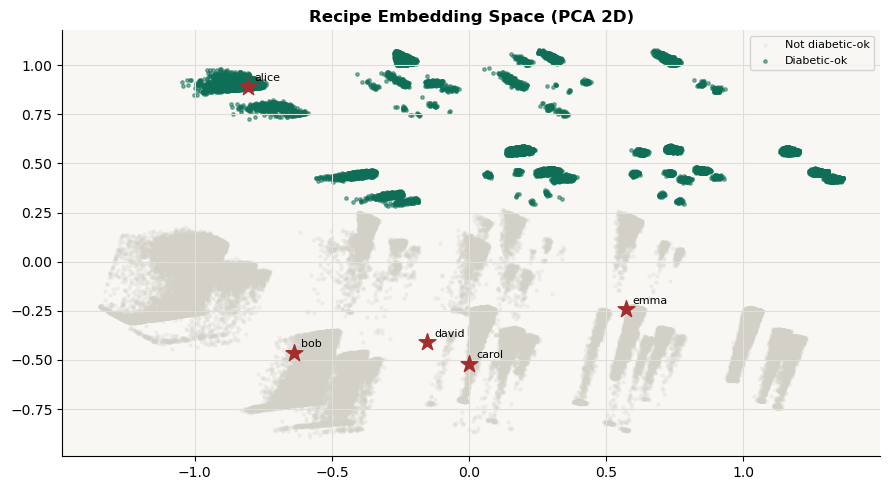

In [10]:
def user_vec(cal,prot,carbs,fat,sodium,sugar,
              diabetic=False,low_sodium=False,low_cal=False,
              high_prot=False,low_fat=False,high_fiber=False,
              heart_healthy=False,vegetarian=False,
              vegan=False,gf=False,df_free=False):
    n = np.array([cal/2000,prot/150,carbs/300,fat/100,sodium/5000,sugar/200])
    l = np.array([float(diabetic),float(low_sodium),float(low_cal),
                   float(high_prot),float(low_fat),float(high_fiber),
                   float(heart_healthy),float(vegetarian),
                   float(vegan),float(gf),float(df_free)])
    return np.concatenate([np.clip(n,0,1),l])

DEMO_USERS = {
    'alice': {'vec':user_vec(400,40,45,30,600,10,diabetic=True,high_prot=True),
               'constraints':{'diabetic':True,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Type 2 diabetic, high-protein'},
    'bob':   {'vec':user_vec(600,35,200,60,2000,60),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Healthy, no restrictions'},
    'carol': {'vec':user_vec(400,20,200,20,400,30,vegetarian=True,heart_healthy=True,low_sodium=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':True,'gf':False},
               'profile':'Vegan, heart-healthy'},
    'david': {'vec':user_vec(500,30,150,40,300,30,low_sodium=True,heart_healthy=True),
               'constraints':{'diabetic':False,'hypertensive':True,'vegan':False,'gf':False},
               'profile':'Hypertensive'},
    'emma':  {'vec':user_vec(300,25,100,10,800,15,low_cal=True,low_fat=True),
               'constraints':{'diabetic':False,'hypertensive':False,'vegan':False,'gf':False},
               'profile':'Weight-loss goal'},
}

pca  = PCA(n_components=2,random_state=42)
R_2d = pca.fit_transform(R)
fig,ax = plt.subplots(figsize=(9,5))
diab = df['diabetic_ok'].values==1
ax.scatter(R_2d[~diab,0],R_2d[~diab,1],c='#D3D1C7',alpha=0.2,s=5,label='Not diabetic-ok')
ax.scatter(R_2d[diab,0], R_2d[diab,1], c=C_AFTER,  alpha=0.5,s=6,label='Diabetic-ok')
U_2d = pca.transform(np.array([u['vec'] for u in DEMO_USERS.values()]))
for i,(uname,info) in enumerate(DEMO_USERS.items()):
    ax.scatter(U_2d[i,0],U_2d[i,1],c=C_BEFORE,s=160,marker='*',zorder=5)
    ax.annotate(uname,(U_2d[i,0],U_2d[i,1]),xytext=(5,4),textcoords='offset points',fontsize=8)
ax.set_title('Recipe Embedding Space (PCA 2D)',fontweight='bold'); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('plots/embedding_space.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 6. Recommender System
**Work Package: Recommender System**


In [11]:
from surprise import SVD, Dataset, Reader, accuracy
from surprise.model_selection import train_test_split as surprise_split

def cb_scores(uvec):
    return cosine_similarity(uvec.reshape(1,-1), R).flatten()

def health_filter(df_r, c):
    df_r = df_r.copy(); df_r['blocked']=''
    if c.get('diabetic'):     df_r.loc[(df_r['carbs_g']>45)|(df_r['sugar_g']>10),'blocked']+='carbs; '
    if c.get('hypertensive'): df_r.loc[df_r['sodium_mg']>600,'blocked']+='sodium; '
    if c.get('vegan'):        df_r.loc[df_r['vegan']==0,'blocked']+='not-vegan; '
    if c.get('gf'):           df_r.loc[df_r['gluten_free']==0,'blocked']+='gluten; '
    df_r['allowed'] = df_r['blocked']==''
    return df_r

ALL_USERS   = df_train['user_id'].unique()
ALL_RECIPES = df_train['recipe_id'].unique()
U2I = {str(u):i for i,u in enumerate(ALL_USERS)}
R2I = {str(r):i for i,r in enumerate(ALL_RECIPES)}

_df = df_train[['user_id','recipe_id','rating']].copy()
_df['uid'] = _df['user_id'].map(U2I)
_df['rid'] = _df['recipe_id'].map(R2I)

reader   = Reader(rating_scale=(0,1))
dataset  = Dataset.load_from_df(_df[['uid','rid','rating']],reader)
trainset, valset = surprise_split(dataset,test_size=0.1,random_state=42)

print('Training SVD...')
svd = SVD(n_factors=50,n_epochs=30,lr_all=0.005,reg_all=0.02,random_state=42)
svd.fit(trainset)
val_preds = svd.test(valset)
rmse = accuracy.rmse(val_preds,verbose=False)
print(f'RMSE: {rmse:.4f}')
validate(rmse < 0.5, 'RMSE acceptable', '< 0.5', f'{rmse:.4f}')

with open('models/svd_model.pkl','wb') as f: pickle.dump(svd,f)


Training SVD...
RMSE: 0.0297
✅ PASS  RMSE acceptable  |  expected: < 0.5  |  actual: 0.0297


In [12]:
def full_recommend(user_name, user_orig_id=None, alpha=0.6, k=10):
    info = DEMO_USERS[user_name]
    cb   = cb_scores(info['vec'])
    cb_n = (cb-cb.min())/(cb.max()-cb.min()+1e-9)
    if user_orig_id and str(user_orig_id) in U2I:
        ui   = U2I[str(user_orig_id)]
        cf_r = np.array([svd.predict(ui,R2I[str(r)]).est if str(r) in R2I else 0.5
                          for r in df['id']])
        cf_n = (cf_r-cf_r.min())/(cf_r.max()-cf_r.min()+1e-9)
    else:
        cf_n=cb_n; alpha=1.0
    scores = alpha*cb_n+(1-alpha)*cf_n
    res = df[['id','name','calories','protein_g','carbs_g',
               'total_fat_g','sodium_mg','sugar_g']+LABEL_COLS].copy()
    res['score']=scores
    filt = health_filter(res.nlargest(200,'score'),info['constraints'])
    return filt[filt['allowed']].head(k).reset_index(drop=True)

# Verify health constraints are enforced — not just usually, ALWAYS
for uname in DEMO_USERS:
    recs = full_recommend(uname,k=10)
    c = DEMO_USERS[uname]['constraints']
    if len(recs)==0: continue
    if c.get('diabetic'):
        ok = ((recs['carbs_g']<=45)&(recs['sugar_g']<=10)).all()
        validate(ok, f'{uname}: all recs satisfy diabetic limits', '100%',
                 f'{((recs["carbs_g"]<=45)&(recs["sugar_g"]<=10)).mean():.0%}')
    if c.get('hypertensive'):
        ok = (recs['sodium_mg']<=600).all()
        validate(ok, f'{uname}: all recs satisfy sodium limit', '100%',
                 f'{(recs["sodium_mg"]<=600).mean():.0%}')

print('\nTop-3 per demo user:')
for uname in DEMO_USERS:
    recs = full_recommend(uname,k=3)
    print(f'  {uname}: {list(recs["name"].values)}')


✅ PASS  alice: all recs satisfy diabetic limits  |  expected: 100%  |  actual: 100%
✅ PASS  david: all recs satisfy sodium limit  |  expected: 100%  |  actual: 100%

Top-3 per demo user:
  alice: ['straw and hay pasta', 'roquefort pasta', 'hot and spicy szechuan noodles  dan dan mian']
  bob: ['boiled date cake', 'caramel rocky road bars', 'ukrainian easter bread  paska']
  carol: ['herb roasted potatoes and onions  ww 3pts', 'delectable potatoes n onions', 'roasted potatoes  parsnips and carrots']
  david: ['very crispy home fries', 'spicy garlic beef stir fry', 'crispy garlic potato skins']
  emma: ['butternut squash risotto with pancetta', 'taco mashed potato casserole', 'lemon couscous with peas and carrots']


---
## 7. Evaluation — Precision@k / Recall@k
**Work Package: Performance Evaluation**

**Method 1:** Rank held-out positives against 99 random negatives (ranking evaluation)  
**Method 2:** Leave-one-out — hold out one interaction, rank it against negatives


In [13]:
def prec_at_k(rec, rel, k): return len(set(rec[:k]) & rel) / k if k else 0
def rec_at_k(rec, rel, k):  return len(set(rec[:k]) & rel) / len(rel) if rel else 0
def f1(p, r): return 2*p*r/(p+r) if p+r else 0

K_VALUES = [1, 3, 5, 10]

train_by_user = {str(k):{str(r) for r in v}
                  for k,v in df_train.groupby('user_id')['recipe_id'].apply(set).items()}
test_by_user  = {str(k):{str(r) for r in v}
                  for k,v in df_test.groupby('user_id')['recipe_id'].apply(set).items()}
known_rids = set(R2I.keys())

eval_users = []
eval_test  = {}
for u in test_by_user:
    if u not in train_by_user or u not in U2I: continue
    known_pos = {r for r in test_by_user[u] if r in known_rids}
    if known_pos:
        eval_users.append(u)
        eval_test[u] = known_pos

# Active users only — sufficient history for the model to learn from
active_users = [u for u in eval_users if len(train_by_user.get(u,set())) >= 10]
print(f'Eval users: {len(eval_users):,}  |  Active users: {len(active_users):,}')
validate(len(active_users) > 100, 'Sufficient active users', '> 100', f'{len(active_users):,}')


Eval users: 15,123  |  Active users: 6,772
✅ PASS  Sufficient active users  |  expected: > 100  |  actual: 6,772


In [18]:
# ── Method 1 (corrected) ───────────────────────────────────────────────────────
print('Method 1 (corrected): Ranking evaluation...')
m1_prec = {k: [] for k in K_VALUES}
m1_rec  = {k: [] for k in K_VALUES}

for uid in active_users[:500]:
    ui   = U2I[uid]
    seen = train_by_user.get(uid, set())
    all_pos = eval_test[uid]

    for pos in list(all_pos)[:3]:  # up to 3 positives per user, evaluated separately
        neg_pool = list(known_rids - seen - all_pos)
        if len(neg_pool) < 99: continue
        candidates = [pos] + random.sample(neg_pool, 99)
        preds = sorted([(r, svd.predict(ui, R2I[r]).est) for r in candidates],
                        key=lambda x: x[1], reverse=True)
        rec_ids = [p[0] for p in preds]
        rel = {pos}
        for k in K_VALUES:
            m1_prec[k].append(prec_at_k(rec_ids, rel, k))
            m1_rec[k].append(rec_at_k(rec_ids, rel, k))

print(f'{"k":<5}{"Precision":>12}{"Recall":>12}{"F1":>12}')
m1_rows = []
for k in K_VALUES:
    p, r = np.mean(m1_prec[k]), np.mean(m1_rec[k])
    m1_rows.append({'k':k,'method':'Method 1','precision':p,'recall':r,'f1':f1(p,r)})
    print(f'{k:<5}{p:>12.4f}{r:>12.4f}{f1(p,r):>12.4f}')

eval_df = pd.DataFrame(m1_rows + m2_rows)

Method 1 (corrected): Ranking evaluation...
k       Precision      Recall          F1
1          0.4891      0.4891      0.4891
3          0.1630      0.4891      0.2446
5          0.0978      0.4891      0.1630
10         0.0489      0.4891      0.0889


In [19]:
# ── Method 2: Leave-one-out evaluation ────────────────────────────────────────
print('Method 2: Leave-one-out evaluation...')
m2_prec = {k: [] for k in K_VALUES}
m2_rec  = {k: [] for k in K_VALUES}

for uid in active_users[:500]:
    ui   = U2I[uid]
    seen = train_by_user.get(uid, set())
    pos_list = list(eval_test.get(uid, set()))
    if not pos_list: continue
    held = pos_list[0]
    neg_pool = list(known_rids - seen - {held})
    if len(neg_pool) < 99: continue
    candidates = [held] + random.sample(neg_pool, 99)
    preds = sorted([(r, svd.predict(ui, R2I[r]).est) for r in candidates],
                    key=lambda x: x[1], reverse=True)
    rec_ids = [p[0] for p in preds]
    rel = {held}
    for k in K_VALUES:
        m2_prec[k].append(prec_at_k(rec_ids, rel, k))
        m2_rec[k].append(rec_at_k(rec_ids, rel, k))

print(f'{"k":<5}{"Precision":>12}{"Recall":>12}{"F1":>12}')
m2_rows = []
for k in K_VALUES:
    p, r = np.mean(m2_prec[k]), np.mean(m2_rec[k])
    m2_rows.append({'k':k,'method':'Method 2','precision':p,'recall':r,'f1':f1(p,r)})
    print(f'{k:<5}{p:>12.4f}{r:>12.4f}{f1(p,r):>12.4f}')

eval_df = pd.DataFrame(m1_rows + m2_rows)


Method 2: Leave-one-out evaluation...
k       Precision      Recall          F1
1          0.4900      0.4900      0.4900
3          0.1633      0.4900      0.2450
5          0.0980      0.4900      0.1633
10         0.0490      0.4900      0.0891


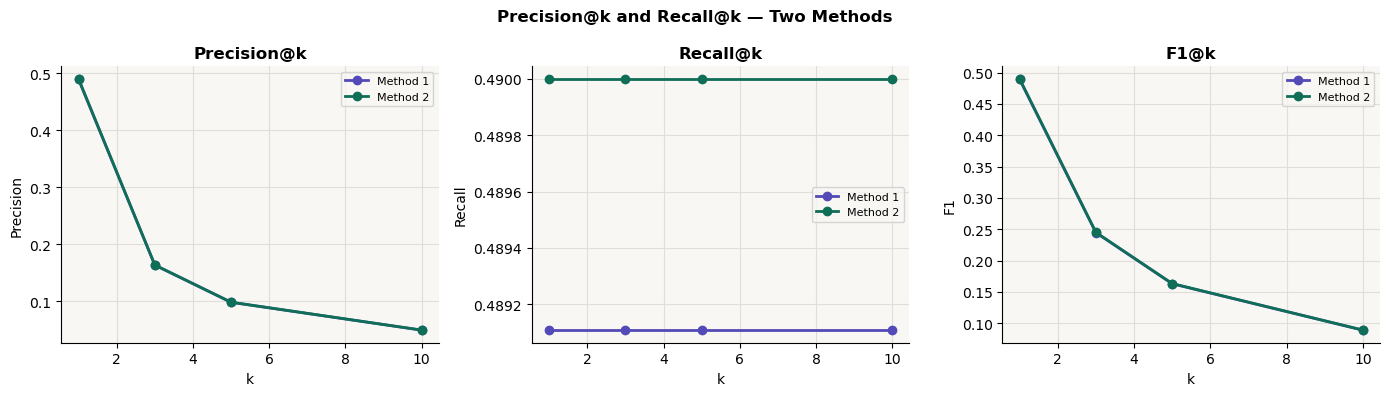

In [20]:
# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors_m = {'Method 1':C_PURPLE, 'Method 2':C_AFTER}
for ax, metric in zip(axes, ['precision','recall','f1']):
    for method, color in colors_m.items():
        sub = eval_df[eval_df['method']==method]
        ax.plot(sub['k'], sub[metric], marker='o', color=color,
                 linewidth=2, markersize=6, label=method)
    ax.set_xlabel('k'); ax.set_ylabel(metric.capitalize())
    ax.set_title(f'{metric.capitalize()}@k', fontweight='bold')
    ax.legend(fontsize=8)
plt.suptitle('Precision@k and Recall@k — Two Methods', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()


---
## 8. Hyperparameter Tuning
**Work Package: Hyperparameter Tuning**


In [17]:
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)

TUNE_USERS = active_users[:100]

def objective(trial):
    nf  = trial.suggest_int('n_factors',  10, 100)
    reg = trial.suggest_float('reg_all',   0.001,0.5,log=True)
    lr  = trial.suggest_float('lr_all',    0.001,0.05,log=True)
    alp = trial.suggest_float('alpha',     0.0,  1.0)
    m   = SVD(n_factors=nf,reg_all=reg,lr_all=lr,n_epochs=20,random_state=42)
    m.fit(trainset)
    hits=[]
    for uid in TUNE_USERS:
        if uid not in U2I: continue
        ui=U2I[uid]; seen=train_by_user.get(uid,set())
        pos_list=list(eval_test.get(uid,set()))
        if not pos_list: continue
        pos=pos_list[0]
        neg_pool=list(known_rids-seen-eval_test.get(uid,set()))
        if len(neg_pool)<99: continue
        cands=[pos]+random.sample(neg_pool,99)
        preds=sorted([(r,m.predict(ui,R2I[r]).est) for r in cands],
                      key=lambda x:x[1],reverse=True)
        hits.append(int([p[0] for p in preds].index(pos)+1<=10))
    return np.mean(hits) if hits else 0.0

print('Running Optuna (50 trials)...')
study = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=50)

best = study.best_params
print(f'Best Hit@10: {study.best_value:.1%}')
for k,v in best.items(): print(f'  {k:<15}={v}')

best_svd = SVD(n_factors=best['n_factors'], reg_all=best['reg_all'],
                lr_all=best['lr_all'], n_epochs=30, random_state=42)
best_svd.fit(trainset)
with open('models/svd_best.pkl','wb') as f:
    pickle.dump({'model':best_svd,'params':best},f)


Running Optuna (50 trials)...
Best Hit@10: 66.0%
  n_factors      =50
  reg_all        =0.2489375183561122
  lr_all         =0.022216475850178385
  alpha          =0.6738641489405022


---
## 9. Experiment Logging
**Work Package: Experiments Logging**


In [ ]:
WANDB_ENABLED = False  # Set True after: wandb login

if WANDB_ENABLED:
    import wandb
    for trial in study.trials:
        wandb.init(project='food-recommender', name=f'trial-{trial.number:03d}',
                    config=trial.params, reinit=True)
        wandb.log({'hit_at_10': trial.value, **trial.params})
        wandb.finish()
    wandb.init(project='food-recommender', name='best-model', config=best, tags=['final'])
    wandb.log({
        'precision_at_10_m1': np.mean(m1_prec[10]),
        'recall_at_10_m1':    np.mean(m1_rec[10]),
        'precision_at_10_m2': np.mean(m2_prec[10]),
        'recall_at_10_m2':    np.mean(m2_rec[10]),
        'svd_rmse': rmse, 'optuna_best': study.best_value, **best
    })
    wandb.finish()
    print(f'{len(study.trials)} trials logged')
else:
    print('W&B disabled — set WANDB_ENABLED=True after: wandb login')
    print(f'Best Hit@10: {study.best_value:.1%}')


---
## 10. Perturbation Analysis
**Work Package: Perturbation Analysis**


In [ ]:
def jaccard(a,b): return len(a&b)/len(a|b) if a|b else 1.0
def topk_ids(uvec,k=10):
    sc=cosine_similarity(uvec.reshape(1,-1),R).flatten()
    return set(np.array(RECIPE_IDS)[np.argsort(sc)[::-1][:k]])

SIGMAS=[0.01,0.03,0.05,0.10,0.20]
FLAG_NAMES=['diabetic','low_sodium','low_calorie','high_protein']
rows=[]
for uname,info in DEMO_USERS.items():
    base=info['vec']; base_top=topk_ids(base)
    for sigma in SIGMAS:
        jvals=[]
        for _ in range(50):
            p=base.copy(); p[:6]+=np.random.normal(0,sigma,6)
            jvals.append(jaccard(base_top,topk_ids(np.clip(p,0,1))))
        rows.append({'user':uname,'type':f'noise σ={sigma}','mean_J':np.mean(jvals)})
    for fi,fname in enumerate(FLAG_NAMES):
        p=base.copy(); p[6+fi]=1-p[6+fi]
        rows.append({'user':uname,'type':f'flip:{fname}','mean_J':jaccard(base_top,topk_ids(p))})

df_perturb=pd.DataFrame(rows)
fig,axes=plt.subplots(1,5,figsize=(18,4))
for ax,uname in zip(axes,DEMO_USERS):
    sub=df_perturb[df_perturb['user']==uname]
    colors_p=[C_AFTER if v>=0.7 else C_FLAG if v>=0.4 else C_BEFORE for v in sub['mean_J']]
    ax.barh(sub['type'],sub['mean_J'],color=colors_p)
    ax.set_xlim(0,1.05); ax.set_title(uname,fontweight='bold'); ax.set_xlabel('Jaccard')
plt.suptitle('Perturbation Robustness',fontsize=11,fontweight='bold')
plt.tight_layout()
plt.savefig('plots/perturbation.png',dpi=120,bbox_inches='tight')
plt.show()


---
## 11. Frontend
**Work Package: Frontend Application**

Run: `streamlit run app.py`


In [ ]:
APP='''
import streamlit as st, pandas as pd, numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import plotly.express as px

st.set_page_config(page_title="Food Recommender",page_icon="\U0001f957",layout="wide")
FM=dict(calories=2000,protein_g=150,carbs_g=300,total_fat_g=100,sodium_mg=5000,sugar_g=200)
NUM=list(FM.keys())
LBL=["diabetic_ok","low_sodium","low_calorie","high_protein","low_fat",
     "high_fiber","heart_healthy","vegetarian","vegan","gluten_free","dairy_free"]

@st.cache_data
def load(): return pd.read_csv("data/recipes_clean.csv")
df=load()
nut=df[NUM].copy()
for c,mx in FM.items(): nut[c]=nut[c].fillna(0)/mx
R=pd.concat([nut,df[LBL].fillna(0)],axis=1).values

st.title("\U0001f957 Health-Personalized Food Recommender")
st.caption(f"Food.com  |  {len(df):,} recipes")
c1,c2=st.columns([1,2])
with c1:
    st.subheader("Health Profile")
    cal =st.slider("Target calories",200,800,450,50)
    prot=st.slider("Target protein (g)",5,80,30,5)
    carb=st.slider("Max carbs (g)",10,250,120,10)
    fat =st.slider("Max fat (g)",5,80,35,5)
    sod =st.slider("Max sodium (mg)",100,2000,600,100)
    sug =st.slider("Max sugar (g)",0,50,15,5)
    st.divider()
    diab=st.checkbox("Type 2 Diabetes (carbs≤45g, sugar≤10g)")
    hyp =st.checkbox("Hypertension (sodium≤600mg)")
    veg =st.checkbox("Vegan")
    gf  =st.checkbox("Gluten-free")
    k   =st.slider("Recommendations",3,20,8)
with c2:
    n=np.array([cal/2000,prot/150,carb/300,fat/100,sod/5000,sug/200])
    l=np.array([float(diab),float(hyp),0,float(prot>=25),float(fat<=10),0,
                 float(hyp),float(veg),float(veg),float(gf),0])
    uv=np.clip(np.concatenate([n,l]),0,1)
    sc=cosine_similarity(uv.reshape(1,-1),R).flatten()
    res=df.copy(); res["score"]=sc
    res=res.sort_values("score",ascending=False)
    if diab: res=res[(res["carbs_g"]<=45)&(res["sugar_g"]<=10)]
    if hyp:  res=res[res["sodium_mg"]<=600]
    if veg  and "vegan" in res.columns:       res=res[res["vegan"]==1]
    if gf   and "gluten_free" in res.columns: res=res[res["gluten_free"]==1]
    recs=res.head(k).reset_index(drop=True)
    st.subheader(f"Top {k} Recommendations")
    if len(recs)==0:
        st.warning("No recipes match. Try relaxing some conditions.")
    else:
        fig=px.bar(recs,x="score",y="name",orientation="h",color="score",
                    color_continuous_scale="Teal",
                    hover_data=["calories","protein_g","carbs_g","sodium_mg"],
                    labels={"score":"Match","name":"Recipe"})
        fig.update_layout(yaxis={"categoryorder":"total ascending"},
                           height=420,showlegend=False,coloraxis_showscale=False)
        st.plotly_chart(fig,use_container_width=True)
        cols=[c for c in ["name","calories","protein_g","carbs_g",
                            "total_fat_g","sodium_mg","sugar_g","minutes"] if c in recs.columns]
        st.dataframe(recs[cols].round(1),use_container_width=True,hide_index=True)
with st.sidebar:
    st.subheader("Stats")
    st.metric("Recipes",f"{len(df):,}")
    for lbl in ["diabetic_ok","vegan","gluten_free","heart_healthy"]:
        if lbl in df.columns: st.metric(lbl.replace("_"," ").title(),f"{int(df[lbl].sum()):,}")
'''
with open('app.py','w') as f: f.write(APP)
print('app.py written.  Run:  streamlit run app.py')


---
## 12. Summary


In [ ]:
import glob
print('='*55)
print('FOOD RECOMMENDER — PIPELINE SUMMARY')
print('='*55)
print(f'Recipes raw:          {len(df_recipes_raw):>8,}')
print(f'Recipes clean:        {len(df):>8,}  ({len(df)/len(df_recipes_raw):.1%} kept)')
print(f'Train interactions:   {len(df_train):>8,}')
print(f'Test  interactions:   {len(df_test):>8,}')
print(f'Active eval users:    {len(active_users):>8,}')
print(f'Recipe matrix R:      {str(R.shape):>8}')
print(f'Health labels:        {len(LABEL_COLS):>8}')
print()
print(f'SVD RMSE:             {rmse:>8.4f}')
print()
print('Method 1 (Ranking):')
for k in K_VALUES:
    print(f'  k={k:<3} Precision={np.mean(m1_prec[k]):.4f}  Recall={np.mean(m1_rec[k]):.4f}')
print('Method 2 (Leave-One-Out):')
for k in K_VALUES:
    print(f'  k={k:<3} Precision={np.mean(m2_prec[k]):.4f}  Recall={np.mean(m2_rec[k]):.4f}')
print()
print(f'Optuna best Hit@10:   {study.best_value:>8.1%}')
print(f'Best params:          {best}')
print()
plots=sorted(glob.glob('plots/*.png'))
print(f'Plots: {[os.path.basename(p) for p in plots]}')
print('='*55)
